In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [ ]:
df['Heart Disease'] = df["Heart Disease"].map({'Presence': 1, 'Absence': 0})

In [ ]:
# Stratified k-Fold
from sklearn.model_selection import StratifiedKFold

X = df.drop(columns=['Heart Disease', 'id'], axis=1)
test = test_df.drop(columns=['id'], axis=1)
test_ids = test_df['id']
y = df['Heart Disease']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
!pip install catboost
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

In [ ]:
from sklearn.metrics import log_loss

In [ ]:
lgb_oof = np.zeros(len(X))
lgb_test_preds = np.zeros(len(test))   # store test predictions

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

    print(f"\nFold {fold+1}")

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.03,
        num_leaves=64,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='logloss',
        callbacks=[lgb.early_stopping(100)]
    )

    # OOF predictions
    lgb_oof[val_idx] = model.predict_proba(X_val)[:, 1]

    # Test predictions (averaged across folds)
    lgb_test_preds += model.predict_proba(test)[:, 1] / skf.n_splits

print("\nLightGBM CV LogLoss:", log_loss(y, lgb_oof))


Fold 1
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.103292 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 422
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 13
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448339 -> initscore=-0.207383
[LightGBM] [Info] Start training from score -0.207383
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[300]	valid_0's binary_logloss: 0.268685

Fold 2
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-c

In [ ]:
xgb_arr = np.zeros(len(X))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = xgb.XGBClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42,
        tree_method='hist'  # faster for large datasets
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    xgb_arr[val_idx] = model.predict_proba(X_val)[:, 1]

print("XGBoost CV LogLoss:", log_loss(y, xgb_arr))


XGBoost CV LogLoss: 0.270162693087656


In [ ]:
cat_features = [
    X.columns.get_loc(col) for col in [
        'Sex',
        'Chest pain type',
        'FBS over 120',
        'EKG results',
        'Exercise angina',
        'Slope of ST',
        'Number of vessels fluro',
        'Thallium'
    ]
]

In [ ]:
cat_arr = np.zeros(len(X))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = CatBoostClassifier(
        iterations=300,
        learning_rate=0.03,
        depth=6,
        eval_metric='Logloss',
        random_state=42,
        verbose=False
    )

    model.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        cat_features=cat_features,
        early_stopping_rounds=100
    )

    cat_arr[val_idx] = model.predict_proba(X_val)[:, 1]

print("CatBoost CV LogLoss:", log_loss(y, cat_arr))


CatBoost CV LogLoss: 0.2708170931567637


In [ ]:
blend_arr = (lgb_arr + xgb_arr + cat_arr) / 3

print("Blended CV LogLoss:", log_loss(y, oof_blend))

Blended CV LogLoss: 0.2698608666166987


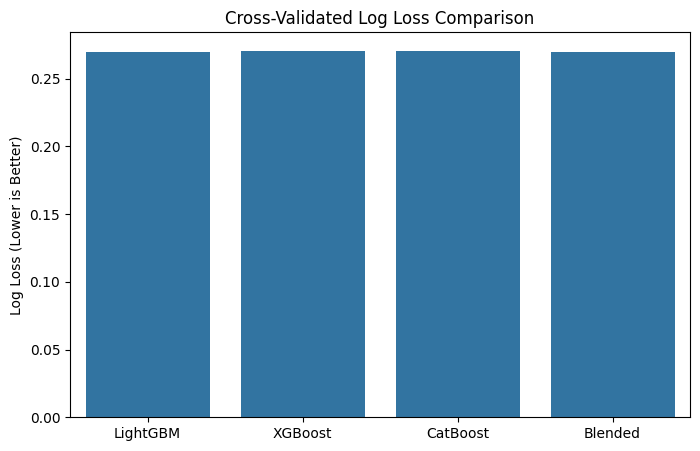

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

lgb_loss = log_loss(y, lgb_arr)
xgb_loss = log_loss(y, xgb_arr)
cat_loss = log_loss(y, cat_arr)
blend_loss = log_loss(y, blend_arr)

models = ['LightGBM', 'XGBoost', 'CatBoost', 'Blended']
losses = [lgb_loss, xgb_loss, cat_loss, blend_loss]

plt.figure(figsize=(8,5))
sns.barplot(x=models, y=losses)
plt.title("Cross-Validated Log Loss Comparison")
plt.ylabel("Log Loss (Lower is Better)")
plt.show()

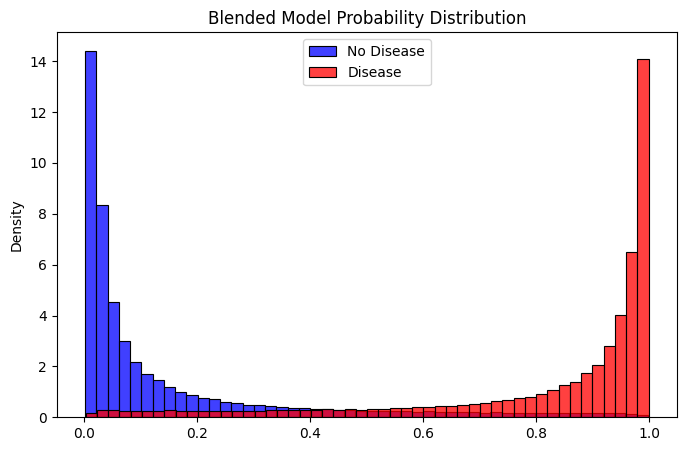

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(blend_arr[y==0], color='blue', label='No Disease', stat='density', bins=50)
sns.histplot(blend_arr[y==1], color='red', label='Disease', stat='density', bins=50)
plt.title("Blended Model Probability Distribution")
plt.legend()
plt.show()

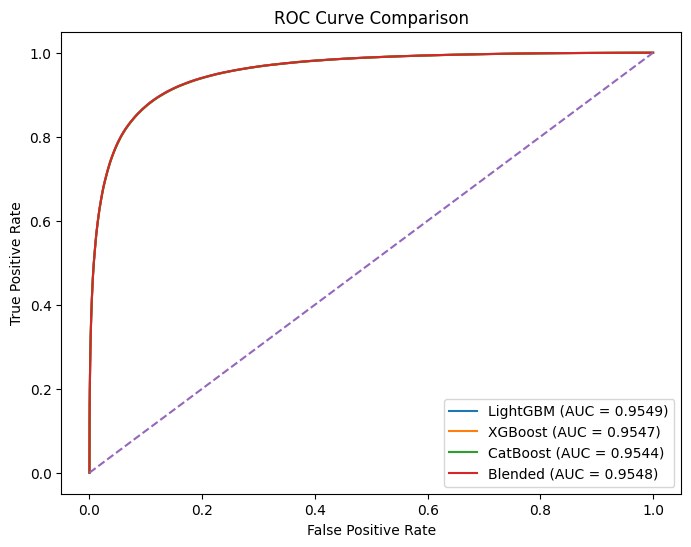

In [ ]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

for preds, name in zip(
    [lgb_arr, xgb_arr, cat_arr, blend_arr],
    ['LightGBM', 'XGBoost', 'CatBoost', 'Blended']
):
    fpr, tpr, _ = roc_curve(y, preds)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [ ]:
submission = pd.DataFrame({
    "id": test_ids,
    "Heart Disease": lgb_test_preds
})

submission.to_csv("submission_lgb.csv", index=False)

GitHub- https://github.com/Prasad0224/Clg-ML_projects.git